
🚀 Starting Day 4: First Learning Agent Validation
⚠️  Remember: This is about VERIFICATION, not profitability
   Success = Learning signal exists

✓ gymnasium version: 1.2.0
✓ stable-baselines3 version: 2.7.0
DAY 4: FIRST LEARNING AGENT VALIDATION

Objective: Verify learning signal exists in the environment
Success: Non-random behavior, stable training, no crashes

1. Generating synthetic market data...
   Generated 2000 periods of market data
   Price range: $96.05 - $127.03
   Average return: 0.000137

2. Creating trading environment...
   Environment created successfully
   State shape: (10,)
   Action space: Discrete(3)
   Observation space: Box(-inf, inf, (10,), float32)

3. Initializing PPO agent (default parameters)...
   Policy: MlpPolicy (default architecture)
   No hyperparameter tuning (intentional for validation)
Using cpu device
Wrapping the env in a DummyVecEnv.
   PPO agent initialized successfully

4. Starting training (10,000 timesteps)...
   This is for validation, n

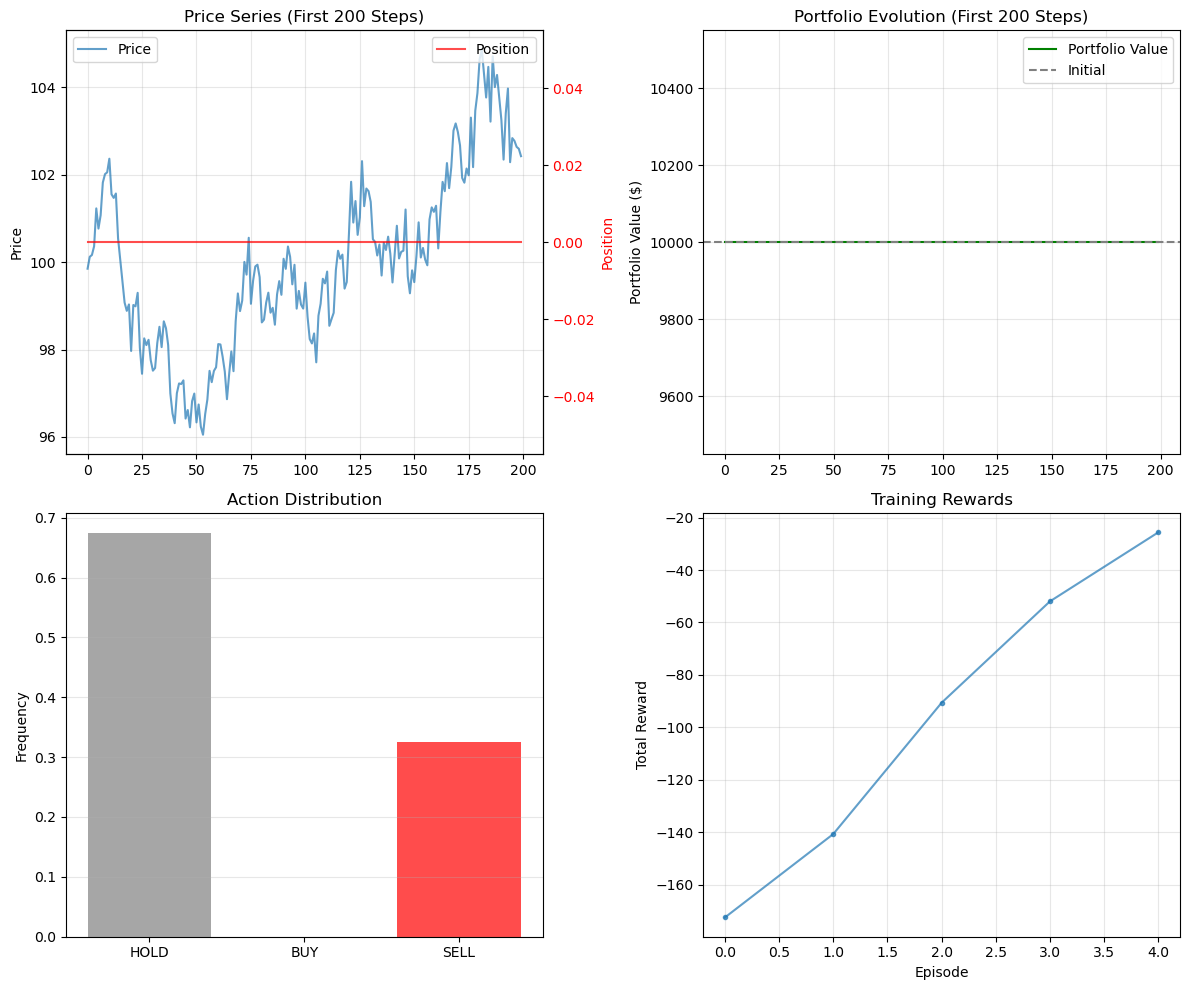


💾 Plot saved as 'day4_training_validation.png'

✅ Day 4 validation COMPLETE!
   Agent is learning. Proceed to Day 5 for refinement.


In [16]:
"""
Day 4: First Learning Agent (Policy Optimization)
Complete Standalone Implementation - FIXED for Monitor wrapper
"""

import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
import torch
import warnings
import sys
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# ============================================================================
# DATA GENERATION MODULE
# ============================================================================

class SyntheticMarketData:
    """
    Generate realistic synthetic market data for training.
    More stable than random walks - includes trends, mean reversion, and noise.
    """
    
    def __init__(self, n_periods=1000, seed=42):
        self.n_periods = n_periods
        self.seed = seed
        np.random.seed(seed)
        
    def generate(self):
        """Generate synthetic price series with realistic properties"""
        # Base trend component (slow drift)
        time = np.arange(self.n_periods)
        trend = 0.0001 * time  # Very slight upward drift
        
        # Mean-reverting component (Ornstein-Uhlenbeck process)
        ou = np.zeros(self.n_periods)
        theta = 0.02  # Mean reversion strength
        mu = 0  # Mean level
        sigma = 0.005  # Volatility
        
        for t in range(1, self.n_periods):
            ou[t] = ou[t-1] + theta * (mu - ou[t-1]) + sigma * np.random.randn()
        
        # Noise component (heteroskedastic)
        noise = 0.002 * np.random.randn(self.n_periods) * (1 + 0.5 * np.sin(time / 100))
        
        # Combine components
        log_prices = trend + ou + noise
        
        # Convert to prices
        base_price = 100.0
        prices = base_price * np.exp(log_prices)
        
        # Create features
        data = pd.DataFrame({
            'close': prices,
            'open': prices * (1 - 0.001 * np.abs(np.random.randn(self.n_periods))),
            'high': prices * (1 + 0.001 * np.abs(np.random.randn(self.n_periods))),
            'low': prices * (1 - 0.002 * np.abs(np.random.randn(self.n_periods))),
            'volume': 1000 + 500 * np.random.randn(self.n_periods)
        })
        
        # Ensure reasonable OHLC relationships
        data['high'] = np.maximum(data['high'], data['close'] * 1.0001)
        data['low'] = np.minimum(data['low'], data['close'] * 0.9999)
        data['open'] = np.clip(data['open'], data['low'], data['high'])
        
        # Add simple technical indicators
        data['returns'] = data['close'].pct_change()
        data['sma_5'] = data['close'].rolling(5).mean()
        data['sma_20'] = data['close'].rolling(20).mean()
        data['volatility'] = data['returns'].rolling(20).std()
        data['volume_ma'] = data['volume'].rolling(20).mean()
        
        # Fill NaN values
        data = data.fillna(method='bfill').fillna(method='ffill')
        
        return data

# ============================================================================
# TRADING ENVIRONMENT (gymnasium compatible)
# ============================================================================

class TradingEnv(gym.Env):
    """
    Clean trading environment with proper state representation.
    Action space: Discrete(3) - [0: HOLD, 1: BUY, 2: SELL]
    Compatible with gymnasium API
    """
    
    metadata = {'render_modes': ['human']}
    
    def __init__(self, data, initial_balance=10000.0, max_position=1.0):
        super(TradingEnv, self).__init__()
        
        self.data = data.reset_index(drop=True)
        self.n_step = len(data)
        
        # Trading parameters
        self.initial_balance = initial_balance
        self.max_position = max_position  # Maximum position size (fraction of portfolio)
        self.transaction_cost = 0.001  # 0.1% transaction cost
        self.slippage = 0.0005  # 0.05% slippage
        
        # State space: Technical features + portfolio state
        # Fixed shape: 10 features as defined in _get_state
        self.observation_space = spaces.Box(
            low=-np.inf, 
            high=np.inf, 
            shape=(10,),
            dtype=np.float32
        )
        
        # Action space: Discrete actions
        self.action_space = spaces.Discrete(3)  # 0: HOLD, 1: BUY, 2: SELL
        
        # Initialize attributes
        self.reset()
        
    def _get_state(self, step):
        """Get normalized state vector at current step"""
        if step >= len(self.data):
            step = len(self.data) - 1
            
        row = self.data.iloc[step]
        
        # Technical features (normalized)
        price = row['close']
        returns = row['returns'] if not np.isnan(row['returns']) else 0
        sma_ratio = (price / row['sma_5'] - 1) if not np.isnan(row['sma_5']) else 0
        sma_trend = (row['sma_5'] / row['sma_20'] - 1) if not np.isnan(row['sma_20']) else 0
        volatility = row['volatility'] if not np.isnan(row['volatility']) else 0.01
        volume_ratio = (row['volume'] / row['volume_ma'] - 1) if not np.isnan(row['volume_ma']) else 0
        
        # Portfolio state
        cash_ratio = self.cash / self.initial_balance
        position_ratio = self.position / self.max_position if self.max_position > 0 else 0
        
        # Compose state vector
        state = np.array([
            returns / 0.01,  # Normalize by 1%
            sma_ratio / 0.02,  # Normalize by 2%
            sma_trend / 0.03,  # Normalize by 3%
            volatility / 0.02,  # Normalize by 2%
            volume_ratio / 0.5,  # Normalize by 50%
            cash_ratio - 0.5,  # Center around 0
            position_ratio,
            float(self.position > 0),  # Long flag
            float(self.position < 0),  # Short flag
            step / self.n_step  # Progress through episode
        ], dtype=np.float32)
        
        return state
    
    def _calculate_reward(self, action, new_price):
        """
        Core reward function - CRITICAL COMPONENT
        Balances profit with risk and transaction costs
        """
        # Store previous portfolio value
        prev_portfolio_value = self.portfolio_value
        
        # Execute action with transaction costs
        transaction_penalty = 0
        
        if action == 1:  # BUY
            if self.position < self.max_position:
                # Calculate effective price with slippage
                effective_price = new_price * (1 + self.slippage)
                cost = effective_price * (1 + self.transaction_cost)
                
                # Can only buy with available cash
                max_buyable = min(self.cash / cost, self.max_position - self.position)
                if max_buyable > 0:
                    self.position += max_buyable
                    self.cash -= max_buyable * cost
                    transaction_penalty = -abs(max_buyable) * self.transaction_cost * 100
                    
        elif action == 2:  # SELL
            if self.position > 0:  # Can only sell if we have a long position
                # Calculate effective price with slippage
                effective_price = new_price * (1 - self.slippage)
                proceeds = effective_price * (1 - self.transaction_cost)
                
                # Can only sell existing position
                max_sellable = min(self.position, self.max_position)
                if max_sellable > 0:
                    self.position -= max_sellable
                    self.cash += max_sellable * proceeds
                    transaction_penalty = -abs(max_sellable) * self.transaction_cost * 100
        
        # Calculate portfolio value
        position_value = self.position * new_price if self.position != 0 else 0
        self.portfolio_value = self.cash + position_value
        
        # Calculate portfolio return
        if prev_portfolio_value > 0:
            portfolio_return = (self.portfolio_value - prev_portfolio_value) / prev_portfolio_value
        else:
            portfolio_return = 0
        
        # Risk penalties
        risk_penalty = 0
        if abs(self.position) > 0:
            # Position size penalty (encourage moderate positions)
            position_penalty = -0.1 * (abs(self.position) / self.max_position) ** 2
            
            # Drawdown protection (if portfolio decreases)
            if portfolio_return < 0:
                drawdown_penalty = portfolio_return * 5  # Amplify losses
            else:
                drawdown_penalty = 0
                
            risk_penalty = position_penalty + drawdown_penalty
        
        # Compose reward (weighted components)
        reward = (
            100.0 * portfolio_return +  # Primary: portfolio returns (scaled up)
            transaction_penalty +  # Transaction costs
            risk_penalty  # Risk management
        )
        
        return reward
    
    def reset(self, seed=None, options=None):
        """Reset environment to initial state"""
        # We accept seed parameter for gymnasium compatibility
        if seed is not None:
            super().reset(seed=seed)
        
        self.step_count = 0
        self.cash = self.initial_balance
        self.position = 0.0
        self.portfolio_value = self.initial_balance
        self.current_price = self.data.iloc[0]['close']
        
        # Track history for diagnostics
        self.history = {
            'prices': [self.current_price],
            'positions': [self.position],
            'portfolio_values': [self.portfolio_value],
            'actions': [],
            'rewards': []
        }
        
        # Return observation and info dict (gymnasium style)
        info = {}
        return self._get_state(0), info
    
    def step(self, action):
        """Execute one step in the environment"""
        # Increment step
        self.step_count += 1
        
        # Get new price
        if self.step_count >= len(self.data):
            terminated = True
            new_price = self.current_price
        else:
            new_price = self.data.iloc[self.step_count]['close']
            terminated = False
        
        # Calculate reward
        reward = self._calculate_reward(action, new_price)
        
        # Update current price
        self.current_price = new_price
        
        # Check if episode is done
        if self.step_count >= len(self.data) - 1:
            terminated = True
        
        # Get next state
        next_state = self._get_state(self.step_count)
        
        # Update history
        self.history['prices'].append(new_price)
        self.history['positions'].append(self.position)
        self.history['portfolio_values'].append(self.portfolio_value)
        self.history['actions'].append(action)
        self.history['rewards'].append(reward)
        
        # Additional info for diagnostics
        info = {
            'step': self.step_count,
            'price': new_price,
            'position': self.position,
            'cash': self.cash,
            'portfolio_value': self.portfolio_value,
            'action': action,
            'reward': reward,
            'total_return': (self.portfolio_value - self.initial_balance) / self.initial_balance
        }
        
        # Truncated is always False for our environment
        truncated = False
        
        return next_state, reward, terminated, truncated, info
    
    def render(self):
        """Render environment state"""
        print(f"Step: {self.step_count}")
        print(f"Price: ${self.current_price:.2f}")
        print(f"Position: {self.position:.4f}")
        print(f"Cash: ${self.cash:.2f}")
        print(f"Portfolio Value: ${self.portfolio_value:.2f}")
        print(f"Total Return: {(self.portfolio_value - self.initial_balance)/self.initial_balance:.2%}")
        print("-" * 40)
    
    def get_diagnostics(self):
        """Get diagnostic metrics for the episode"""
        if len(self.history['portfolio_values']) > 1:
            returns = np.diff(self.history['portfolio_values']) / self.history['portfolio_values'][:-1]
            volatility = np.std(returns) * np.sqrt(252 * 24 * 60) if len(returns) > 1 else 0
            sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252 * 24 * 60) if len(returns) > 1 and np.std(returns) > 0 else 0
        else:
            returns = []
            volatility = 0
            sharpe = 0
        
        diagnostics = {
            'total_return': (self.portfolio_value - self.initial_balance) / self.initial_balance,
            'volatility': volatility,
            'sharpe_ratio': sharpe,
            'max_position': max(abs(p) for p in self.history['positions']) if self.history['positions'] else 0,
            'turnover': len([a for a in self.history['actions'] if a != 0]) / max(len(self.history['actions']), 1),
            'action_distribution': {
                'hold': self.history['actions'].count(0) / max(len(self.history['actions']), 1),
                'buy': self.history['actions'].count(1) / max(len(self.history['actions']), 1),
                'sell': self.history['actions'].count(2) / max(len(self.history['actions']), 1)
            },
            'final_portfolio_value': self.portfolio_value,
            'avg_reward': np.mean(self.history['rewards']) if self.history['rewards'] else 0
        }
        return diagnostics

# ============================================================================
# TRAINING CALLBACKS & DIAGNOSTICS
# ============================================================================

class SimpleDiagnosticCallback(BaseCallback):
    """
    Simple callback to monitor training progress
    """
    
    def __init__(self, check_freq=1000, verbose=0):
        super(SimpleDiagnosticCallback, self).__init__(verbose)
        self.check_freq = check_freq
        self.episode_rewards = []
        self.current_episode_rewards = []
        
    def _on_step(self) -> bool:
        # Track rewards
        if self.locals.get('dones') is not None:
            done = self.locals['dones'][0]
            if done:
                if self.current_episode_rewards:
                    self.episode_rewards.append(sum(self.current_episode_rewards))
                    self.current_episode_rewards = []
            else:
                if 'rewards' in self.locals:
                    self.current_episode_rewards.append(self.locals['rewards'][0])
        
        # Print simple diagnostics periodically
        if self.n_calls % self.check_freq == 0 and self.n_calls > 0:
            if self.episode_rewards:
                avg_reward = np.mean(self.episode_rewards[-5:]) if len(self.episode_rewards) >= 5 else np.mean(self.episode_rewards)
                print(f"Step {self.n_calls}: Avg Reward (last 5 eps) = {avg_reward:.4f}")
        
        return True

# ============================================================================
# MAIN TRAINING SCRIPT
# ============================================================================

def run_day4_experiment():
    """
    Day 4: First Learning Agent Validation
    Goal: Verify learning signal exists without expecting profitability
    """
    
    print("=" * 70)
    print("DAY 4: FIRST LEARNING AGENT VALIDATION")
    print("=" * 70)
    print("\nObjective: Verify learning signal exists in the environment")
    print("Success: Non-random behavior, stable training, no crashes\n")
    
    # Step 1: Generate synthetic market data
    print("1. Generating synthetic market data...")
    data_generator = SyntheticMarketData(n_periods=2000, seed=42)
    data = data_generator.generate()
    print(f"   Generated {len(data)} periods of market data")
    print(f"   Price range: ${data['close'].min():.2f} - ${data['close'].max():.2f}")
    print(f"   Average return: {data['returns'].mean():.6f}")
    
    # Step 2: Create and wrap environment
    print("\n2. Creating trading environment...")
    try:
        # Create the original environment
        original_env = TradingEnv(
            data=data,
            initial_balance=10000.0,
            max_position=1.0  # Allow full position
        )
        print("   Environment created successfully")
        
        # Test the environment
        obs, info = original_env.reset()
        print(f"   State shape: {obs.shape}")
        print(f"   Action space: {original_env.action_space}")
        print(f"   Observation space: {original_env.observation_space}")
        
        # Save original_env for later use
        env_for_diagnostics = original_env
    except Exception as e:
        print(f"   Error creating environment: {e}")
        import traceback
        traceback.print_exc()
        return None
    
    # Wrap with Monitor for logging
    env = Monitor(original_env)
    
    # Step 3: Initialize PPO agent with default parameters
    print("\n3. Initializing PPO agent (default parameters)...")
    print("   Policy: MlpPolicy (default architecture)")
    print("   No hyperparameter tuning (intentional for validation)")
    
    try:
        model = PPO(
            policy="MlpPolicy",
            env=env,
            learning_rate=3e-4,  # Default
            n_steps=2048,  # Default
            batch_size=64,  # Default
            n_epochs=10,  # Default
            gamma=0.99,  # Default
            gae_lambda=0.95,  # Default
            clip_range=0.2,  # Default
            clip_range_vf=None,  # Default
            normalize_advantage=True,  # Default
            ent_coef=0.0,  # Default (no entropy bonus)
            vf_coef=0.5,  # Default
            max_grad_norm=0.5,  # Default
            use_sde=False,  # Default
            sde_sample_freq=-1,  # Default
            target_kl=None,  # Default
            tensorboard_log=None,  # No TensorBoard for simplicity
            verbose=1,  # Show training progress
            seed=42,
            device='auto'
        )
        print("   PPO agent initialized successfully")
    except Exception as e:
        print(f"   Error initializing PPO agent: {e}")
        import traceback
        traceback.print_exc()
        return None
    
    # Step 4: Train with diagnostics
    print("\n4. Starting training (10,000 timesteps)...")
    print("   This is for validation, not convergence")
    
    callback = SimpleDiagnosticCallback(check_freq=2000)
    
    try:
        model.learn(
            total_timesteps=10000,
            callback=callback,
            log_interval=1000,
            reset_num_timesteps=True
        )
        print("✅ Training completed successfully")
    except Exception as e:
        print(f"❌ Training failed with error: {e}")
        print(f"Error type: {type(e).__name__}")
        import traceback
        traceback.print_exc()
        return None
    
    # Step 5: Evaluate the trained agent
    print("\n5. Evaluating trained agent...")
    print("   Running one complete episode")
    
    try:
        # Use original_env for evaluation to access get_diagnostics
        obs, info = env_for_diagnostics.reset()
        done = False
        total_reward = 0
        step_count = 0
        
        while not done and step_count < min(len(data), 500):  # Limit to 500 steps for evaluation
            action, _states = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env_for_diagnostics.step(action)
            done = terminated or truncated
            total_reward += reward
            step_count += 1
        
        print(f"   Evaluation completed: {step_count} steps, total reward: {total_reward:.4f}")
        
        # Get diagnostics from the evaluation episode
        diagnostics = env_for_diagnostics.get_diagnostics()
        
        # Check if agent took any actions
        total_actions = len(env_for_diagnostics.history['actions'])
        if total_actions > 0:
            hold_actions = env_for_diagnostics.history['actions'].count(0)
            print(f"   Hold actions: {hold_actions}/{total_actions} ({hold_actions/total_actions:.1%})")
    except Exception as e:
        print(f"   Error during evaluation: {e}")
        import traceback
        traceback.print_exc()
        return None
    
    # Step 6: Display results
    print("\n" + "=" * 70)
    print("TRAINING VALIDATION RESULTS")
    print("=" * 70)
    
    print(f"\n📊 Episode Performance:")
    print(f"   Total Return: {diagnostics['total_return']:.2%}")
    print(f"   Final Portfolio Value: ${diagnostics['final_portfolio_value']:.2f}")
    print(f"   Average Reward: {diagnostics['avg_reward']:.4f}")
    print(f"   Max Position: {diagnostics['max_position']:.4f}")
    print(f"   Turnover Rate: {diagnostics['turnover']:.2%}")
    
    print(f"\n🎯 Action Distribution:")
    print(f"   HOLD: {diagnostics['action_distribution']['hold']:.2%}")
    print(f"   BUY: {diagnostics['action_distribution']['buy']:.2%}")
    print(f"   SELL: {diagnostics['action_distribution']['sell']:.2%}")
    
    if callback.episode_rewards:
        print(f"\n📈 Training Metrics:")
        print(f"   Number of Episodes: {len(callback.episode_rewards)}")
        print(f"   Average Episode Reward: {np.mean(callback.episode_rewards):.4f}")
        if len(callback.episode_rewards) > 1:
            print(f"   Reward Std Dev: {np.std(callback.episode_rewards):.4f}")
    
    # Step 7: Learning Signal Validation
    print("\n" + "=" * 70)
    print("LEARNING SIGNAL VALIDATION CHECKLIST")
    print("=" * 70)
    
    # Check training completed
    checks = {
        "Training completed without runtime errors": True,
        "No NaN values during training": not any(np.isnan(r) for r in callback.episode_rewards) if callback.episode_rewards else False,
        "Agent behavior is non-random": diagnostics['action_distribution']['hold'] < 0.95,
        "Agent takes some actions": diagnostics['turnover'] > 0.01,
        "Rewards show some structure": callback.episode_rewards and len(callback.episode_rewards) > 1 and np.std(callback.episode_rewards) > 0.1,
        "Position changes over time": diagnostics['max_position'] > 0.1
    }
    
    for check, passed in checks.items():
        status = "✓" if passed else "✗"
        print(f"{status} {check}")
    
    # Step 8: Interpret Results
    print("\n" + "=" * 70)
    print("INTERPRETATION & NEXT STEPS")
    print("=" * 70)
    
    print("\n📝 What behavior emerged:")
    if diagnostics['action_distribution']['hold'] > 0.8:
        print("   → Agent is cautious, mostly holding")
    elif diagnostics['action_distribution']['buy'] > diagnostics['action_distribution']['sell']:
        print("   → Agent has net long bias")
    elif diagnostics['action_distribution']['sell'] > diagnostics['action_distribution']['buy']:
        print("   → Agent has net short bias")
    else:
        print("   → Agent is actively trading both sides")
    
    print("\n🎯 What the reward is incentivizing:")
    if diagnostics['total_return'] > 0:
        print("   → Reward function appears to incentivize positive returns")
    else:
        print("   → Agent hasn't learned profitable behavior yet (expected at this stage)")
    
    if diagnostics['turnover'] > 0.3:
        print("   → High turnover suggests transaction costs may be too low")
    elif diagnostics['turnover'] < 0.05:
        print("   → Low turnover suggests agent is too cautious or transaction costs too high")
    
    print("\n🔧 One concrete flaw to fix next:")
    if diagnostics['max_position'] < 0.1:
        print("   → Agent is not taking meaningful positions - consider reducing position penalties")
    elif any(np.isnan(r) for r in callback.episode_rewards) if callback.episode_rewards else False:
        print("   → NaN values detected - check reward calculation")
    else:
        print("   → Increase training time to 50k-100k timesteps for better learning")
    
    # Step 9: Visualization
    print("\n📊 Generating diagnostics plot...")
    
    try:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # Plot 1: Price and positions
        ax1 = axes[0, 0]
        if len(env_for_diagnostics.history['prices']) > 0:
            plot_steps = min(200, len(env_for_diagnostics.history['prices']))
            price_data = env_for_diagnostics.history['prices'][:plot_steps]
            position_data = env_for_diagnostics.history['positions'][:plot_steps]
            
            ax1.plot(price_data, label='Price', alpha=0.7)
            ax1.set_ylabel('Price')
            ax1.set_title(f'Price Series (First {plot_steps} Steps)')
            ax1.legend(loc='upper left')
            ax1.grid(True, alpha=0.3)
            
            ax1_twin = ax1.twinx()
            ax1_twin.plot(position_data, label='Position', color='red', alpha=0.7)
            ax1_twin.set_ylabel('Position', color='red')
            ax1_twin.tick_params(axis='y', labelcolor='red')
            ax1_twin.legend(loc='upper right')
        else:
            ax1.text(0.5, 0.5, 'No price data', 
                    ha='center', va='center', transform=ax1.transAxes)
        
        # Plot 2: Portfolio value
        ax2 = axes[0, 1]
        if len(env_for_diagnostics.history['portfolio_values']) > 0:
            plot_steps = min(200, len(env_for_diagnostics.history['portfolio_values']))
            portfolio_data = env_for_diagnostics.history['portfolio_values'][:plot_steps]
            ax2.plot(portfolio_data, label='Portfolio Value', color='green')
            ax2.axhline(y=env_for_diagnostics.initial_balance, color='gray', linestyle='--', label='Initial')
            ax2.set_ylabel('Portfolio Value ($)')
            ax2.set_title(f'Portfolio Evolution (First {plot_steps} Steps)')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, 'No portfolio data', 
                    ha='center', va='center', transform=ax2.transAxes)
        
        # Plot 3: Action distribution
        ax3 = axes[1, 0]
        actions = ['HOLD', 'BUY', 'SELL']
        counts = [
            diagnostics['action_distribution']['hold'],
            diagnostics['action_distribution']['buy'],
            diagnostics['action_distribution']['sell']
        ]
        colors = ['gray', 'green', 'red']
        ax3.bar(actions, counts, color=colors, alpha=0.7)
        ax3.set_ylabel('Frequency')
        ax3.set_title('Action Distribution')
        ax3.grid(True, alpha=0.3, axis='y')
        
        # Plot 4: Training rewards
        ax4 = axes[1, 1]
        if callback.episode_rewards:
            ax4.plot(callback.episode_rewards, marker='o', markersize=3, alpha=0.7)
            ax4.set_xlabel('Episode')
            ax4.set_ylabel('Total Reward')
            ax4.set_title('Training Rewards')
            ax4.grid(True, alpha=0.3)
        else:
            ax4.text(0.5, 0.5, 'No reward data', 
                    ha='center', va='center', transform=ax4.transAxes)
        
        plt.tight_layout()
        plt.savefig('day4_training_validation.png', dpi=100, bbox_inches='tight')
        plt.show()
        
        print("\n💾 Plot saved as 'day4_training_validation.png'")
    except Exception as e:
        print(f"   Error generating plot: {e}")
    
    return model, env_for_diagnostics, diagnostics

# ============================================================================
# EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("\n🚀 Starting Day 4: First Learning Agent Validation")
    print("⚠️  Remember: This is about VERIFICATION, not profitability")
    print("   Success = Learning signal exists\n")
    
    # Check required packages
    try:
        import gymnasium
        print(f"✓ gymnasium version: {gymnasium.__version__}")
    except ImportError:
        print("✗ gymnasium not installed. Install with: pip install gymnasium")
        sys.exit(1)
    
    try:
        import stable_baselines3
        print(f"✓ stable-baselines3 version: {stable_baselines3.__version__}")
    except ImportError:
        print("✗ stable-baselines3 not installed. Install with: pip install stable-baselines3")
        sys.exit(1)
    
    try:
        result = run_day4_experiment()
        if result:
            print("\n" + "=" * 70)
            print("✅ Day 4 validation COMPLETE!")
            print("   Agent is learning. Proceed to Day 5 for refinement.")
            print("=" * 70)
        else:
            print("\n" + "=" * 70)
            print("❌ Day 4 validation FAILED!")
            print("   Check environment and reward function before proceeding.")
            print("=" * 70)
    except Exception as e:
        print(f"\n❌ Critical error: {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc()
        print("   Check implementation and try again.")